In [34]:
# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# DiCE imports
import dice_ml
from dice_ml.utils import helpers  # helper functions

In [3]:
%load_ext autoreload
%autoreload 2

import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

In [80]:
dataset = helpers.load_adult_income_dataset()
target = dataset["income"].astype(int)

In [81]:
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

In [82]:
# Step 1: dice_ml.Data
d = dice_ml.Data(
    dataframe=train_dataset, 
    continuous_features=['age', 'hours_per_week'], 
    categorical_features_ordering={'education': ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']},
    outcome_name='income'
)


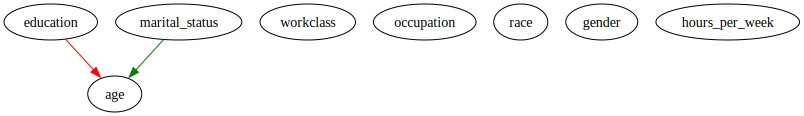

In [124]:
# step 2 constraints
constraints = dice_ml.CausalConstraints(data_interface=d)
constraints.add_single_constraint("cannot_decrease", feature="age")
constraints.add_single_constraint("cannot_decrease", feature="education")
constraints.add_single_constraint("cannot_change", feature="race")
constraints.add_single_constraint("cannot_change", feature="gender")
constraints.add_constraint("increase_with", feature="age", depends_on="education")
constraints.add_constraint("increase_on_change", feature="age", depends_on="marital_status")
constraints.create_constraint_visualisation()

# print(constraints.constraints)

In [156]:
backend = 'TF2'  # needs tensorflow installed
ML_modelpath = helpers.get_adult_income_modelpath(backend=backend)
# Step 2: dice_ml.Model
m = dice_ml.Model(model_path=ML_modelpath, backend=backend, func="ohe-min-max")

In [157]:
# Step 3: initiate DiCE
exp = dice_ml.Dice(d, m, method="gradient")

/Users/izzimillar/Documents/cam/part_iii/L193/DiCE/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/izzimillar/Documents/cam/part_iii/L193/DiCE/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [46]:
import random
random.seed(42)

random_ids = random.sample(list(x_test.index), 50)
random_instaces = x_test.loc[random_ids]


In [ ]:
def display_graph(values, no_cfs, title="", ylim=None, ylabel="", marker='*', ls='-'):
    plt.plot(no_cfs, values, marker, ls=ls)
    plt.title(title)
    plt.ylim(ylim)
    plt.xlim((no_cfs[0], no_cfs[-1]))
    plt.xlabel("Number of cfs")
    plt.ylabel(ylabel)
    plt.show()
    

In [47]:
cat_div = []
cat_prox = []
cont_div = []
cont_prox = []
count_div = []
spars = []
val = []

for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite", causal_constraints=constraints)

	cat_div.append(cfs.calculate_cat_diversity())
	cat_prox.append(cfs.calculate_cat_proximity())
	cont_div.append(cfs.calculate_cont_diversity())
	cont_prox.append(cfs.calculate_cont_proximity())
	spars.append(cfs.calculate_cont_sparsity())
	count_div.append(cfs.calculate_count_diversity())
	val.append(cfs.calculate_validity(i+1))



  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:09<07:28,  9.16s/it]

Diverse Counterfactuals found! total time taken: 00 min 09 sec


  4%|▍         | 2/50 [00:15<06:08,  7.67s/it]

Diverse Counterfactuals found! total time taken: 00 min 06 sec


...

Diverse Counterfactuals found! total time taken: 00 min 35 sec


 98%|█████████▊| 49/50 [2:45:33<02:22, 142.45s/it]

Diverse Counterfactuals found! total time taken: 01 min 17 sec


100%|██████████| 50/50 [2:51:06<00:00, 205.34s/it]

No Counterfactuals found for the given configuation, perhaps try with different  values of proximity (or diversity) weights or learning rate... ; total time taken: 05 min 33 sec


In [158]:
act = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instances, total_CFs=i+1, desired_class="opposite", causal_constraints=constraints)
	act.append(cfs.calculate_actionability(constraints))

nact = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instances, total_CFs=i+1, desired_class="opposite")
	nact.append(cfs.calculate_actionability(constraints))

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


 20%|██        | 1/5 [00:06<00:26,  6.69s/it]

Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


...

 60%|██████    | 3/5 [02:07<01:26, 43.27s/it]

Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


 80%|████████  | 4/5 [03:10<00:50, 50.92s/it]

Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


100%|██████████| 5/5 [04:17<00:00, 51.43s/it]


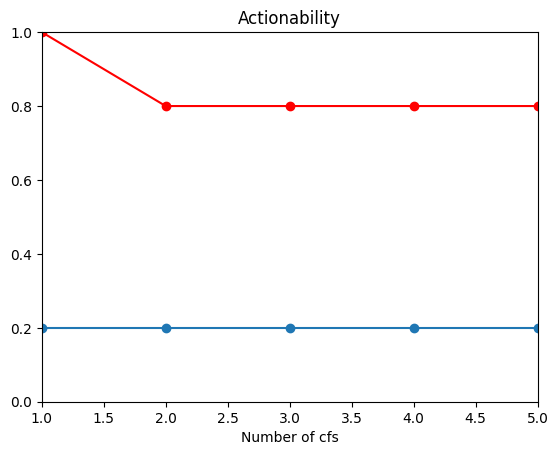

In [160]:
compare_values(act, nact, no_cfs, "Actionability", ylim=(0,1))

In [53]:
print(cat_div)
print(cat_prox)
print(cont_div)
print(cont_prox)
print(count_div)
print(spars)
print(val)

[0.0, 0.13000000000000003, 0.12111111111111107, 0.10166666666666664, 0.08800000000000001]
[0.6166666666666667, 0.5400000000000001, 0.5127777777777779, 0.42722222222222217, 0.4266666666666667]
[0.0, np.float64(2.2425), np.float64(2.483666666666667), np.float64(2.3005), np.float64(2.3552666666666666)]
[np.float64(-2.8135000000000003), np.float64(-3.4842499999999994), np.float64(-3.809666666666666), np.float64(-3.1735), np.float64(-3.238850000000001)]
[0.0, 0.28, 0.2791666666666666, 0.22333333333333333, 0.20783333333333334]
[0.95, 0.89, 0.9, 0.725, 0.73]
[0.96, 0.91, 0.9133333333333334, 0.735, 0.7119999999999999]


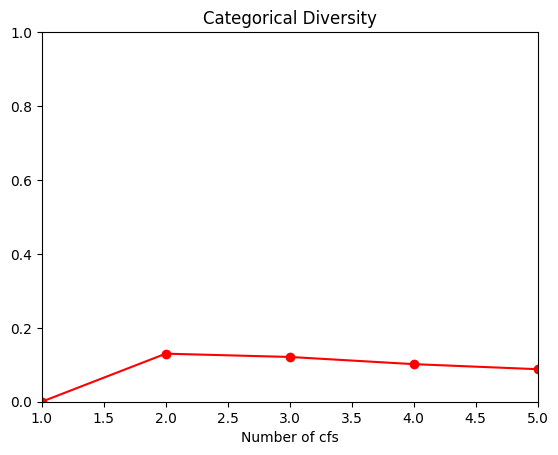

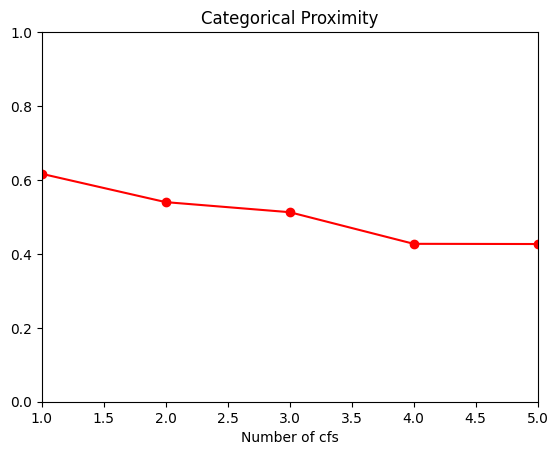

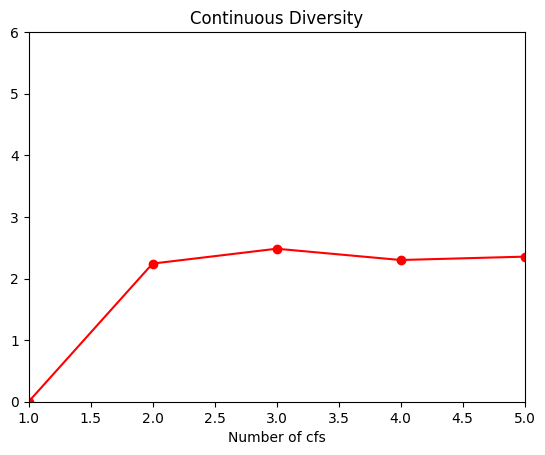

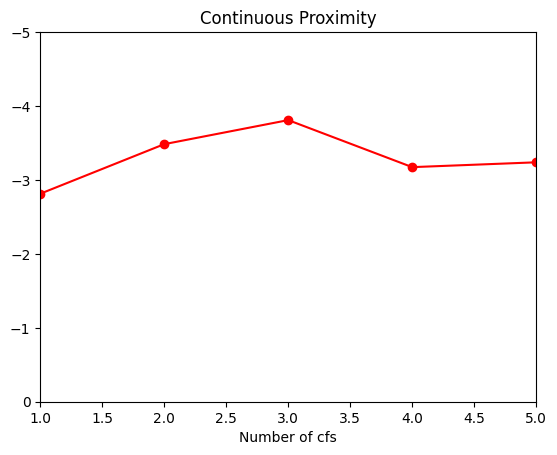

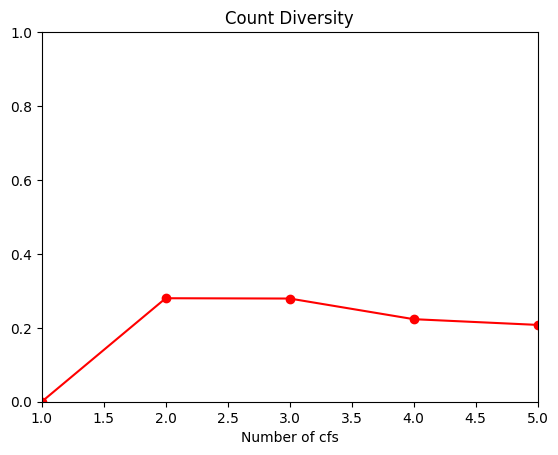

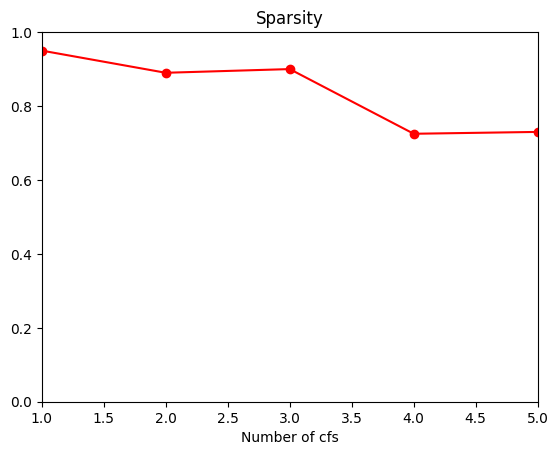

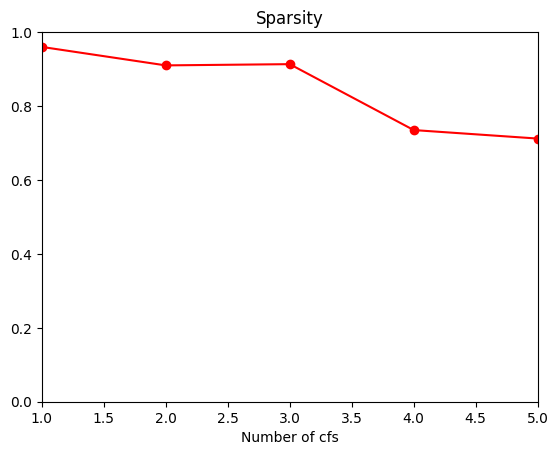

In [ ]:
display_graph(cat_div, np.arange(1, 6), title="Categorical Diversity", ylim=(0, 1.0), marker='ro')
display_graph(cat_prox, np.arange(1, 6), title="Categorical Proximity", ylim=(0, 1.0), marker='ro')
display_graph(cont_div, np.arange(1, 6), title="Continuous Diversity", ylim=(0, 6), marker='ro')
display_graph(cont_prox, np.arange(1, 6), title="Continuous Proximity", ylim=(0, -5), marker='ro')
display_graph(count_div, np.arange(1, 6), title="Count Diversity", ylim=(0, 1.0), marker='ro')
display_graph(spars, np.arange(1, 6), title="Sparsity", ylim=(0, 1.0), marker='ro')
display_graph(val, np.arange(1, 6), title="Validity", ylim=(0, 1.0), marker='ro')


In [56]:
ncat_div = []
ncat_prox = []
ncont_div = []
ncont_prox = []
ncount_div = []
nspars = []
nval = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite")

	ncat_div.append(cfs.calculate_cat_diversity())
	ncat_prox.append(cfs.calculate_cat_proximity())
	ncont_div.append(cfs.calculate_cont_diversity())
	ncont_prox.append(cfs.calculate_cont_proximity())
	nspars.append(cfs.calculate_cont_sparsity())
	ncount_div.append(cfs.calculate_count_diversity())
	nval.append(cfs.calculate_validity(i+1))

  0%|          | 0/50 [00:00<?, ?it/s]

Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


  2%|▏         | 1/50 [00:56<45:54, 56.21s/it]

Diverse Counterfactuals found! total time taken: 00 min 56 sec
Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


  4%|▍         | 2/50 [01:01<21:05, 26.37s/it]

...

No Counterfactuals found for the given configuation, perhaps try with different  values of proximity (or diversity) weights or learning rate... ; total time taken: 05 min 25 sec
Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


 98%|█████████▊| 49/50 [2:54:31<04:29, 269.50s/it]

No Counterfactuals found for the given configuation, perhaps try with different  values of proximity (or diversity) weights or learning rate... ; total time taken: 05 min 27 sec
Generating counterfactuals without using casual constraints. Some counterfactuals may not be actionable.


100%|██████████| 50/50 [2:59:58<00:00, 215.97s/it]

Only 1 (required 5)  Diverse Counterfactuals found for the given configuation, perhaps try with different values of proximity (or diversity) weights or learning rate... ; total time taken: 05 min 27 sec


In [57]:
print(ncat_div)
print(ncat_prox)
print(ncont_div)
print(ncont_prox)
print(ncount_div)
print(nspars)
print(nval)

[0.0, 0.04, 0.011111111111111112, 0.018333333333333333, 0.012]
[0.35, 0.35500000000000015, 0.2744444444444445, 0.3141666666666667, 0.30133333333333334]
[0.0, np.float64(1.9555000000000005), np.float64(1.9240000000000002), np.float64(2.0061666666666667), np.float64(2.0250000000000004)]
[np.float64(-1.347), np.float64(-1.58725), np.float64(-1.3823333333333332), np.float64(-1.7472500000000002), np.float64(-1.8192999999999997)]
[0.0, 0.1675, 0.12333333333333331, 0.12458333333333334, 0.11925000000000001]
[0.92, 0.78, 0.6099999999999999, 0.7725, 0.7339999999999999]
[0.98, 0.8, 0.66, 0.695, 0.68]


In [131]:
def compare_values(val1, val2, no_cfs, title="", ylim=None):
    plt.plot(no_cfs, val1, "ro", ls="-")
    plt.plot(no_cfs, val2, "o", ls="-")
    plt.title(title)
    plt.xlabel("Number of cfs")
    plt.ylim(ylim)
    plt.xlim(no_cfs[0], no_cfs[-1])
    plt.show()


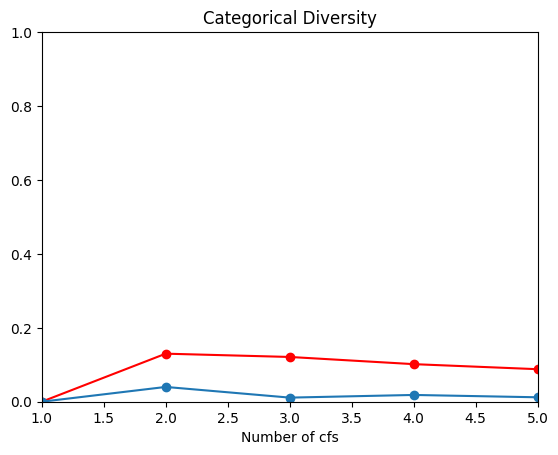

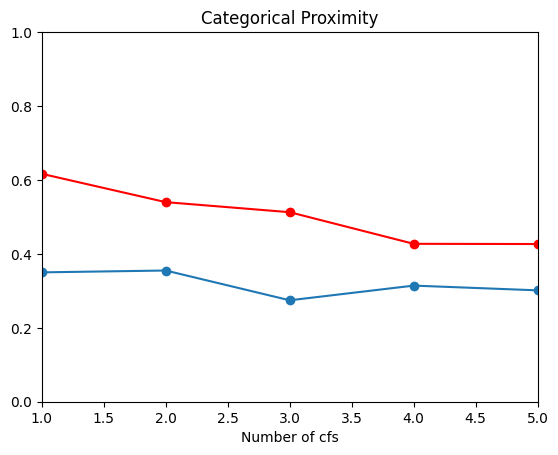

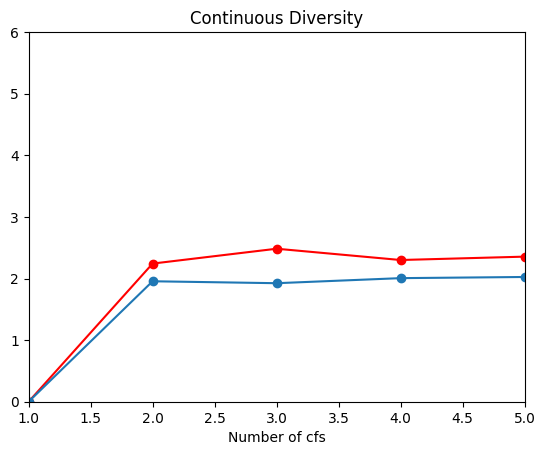

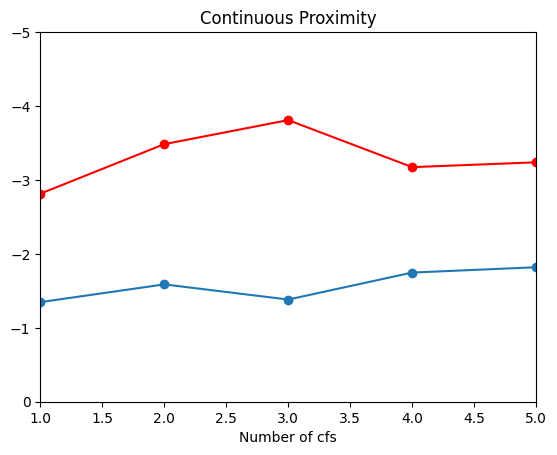

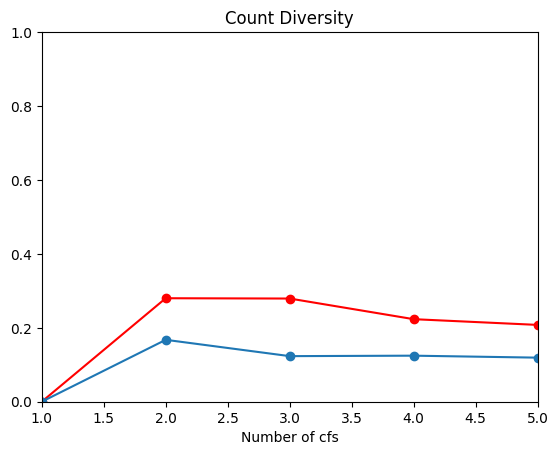

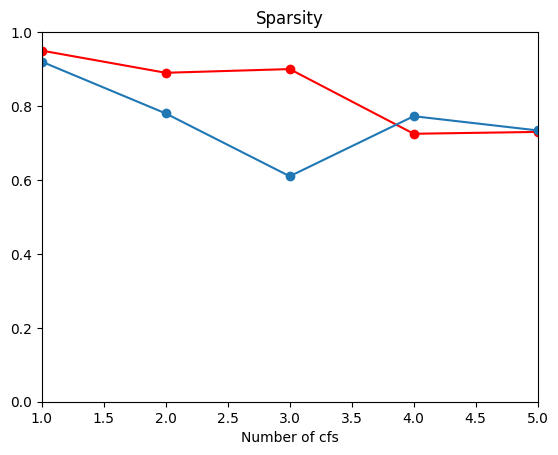

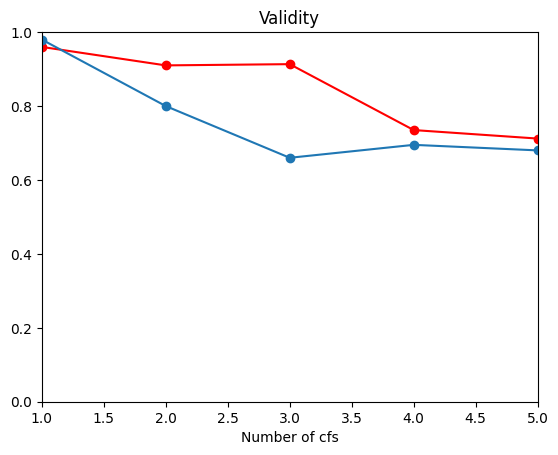

In [132]:
no_cfs = np.arange(1,6)
# display_graph(cat_div, np.arange(1, 6), title="Categorical Diversity", ylim=(0, 1.0), marker='ro')
# display_graph(cat_prox, np.arange(1, 6), title="Categorical Proximity", ylim=(0, 1.0), marker='ro')
# display_graph(cont_div, np.arange(1, 6), title="Continuous Diversity", ylim=(0, 6), marker='ro')
# display_graph(cont_prox, np.arange(1, 6), title="Continuous Proximity", ylim=(0, -5), marker='ro')
# display_graph(count_div, np.arange(1, 6), title="Count Diversity", ylim=(0, 1.0), marker='ro')
# display_graph(spars, np.arange(1, 6), title="Sparsity", ylim=(0, 1.0), marker='ro')
# display_graph(val, np.arange(1, 6), title="Validity", ylim=(0, 1.0), marker='ro')

compare_values(cat_div, ncat_div, no_cfs, "Categorical Diversity", ylim=(0,1))
compare_values(cat_prox, ncat_prox, no_cfs, "Categorical Proximity", ylim=(0,1))
compare_values(cont_div, ncont_div, no_cfs, "Continuous Diversity", ylim=(0,6))
compare_values(cont_prox, ncont_prox, no_cfs, "Continuous Proximity", ylim=(0,-5))
compare_values(count_div, ncount_div, no_cfs, "Count Diversity", ylim=(0,1))
compare_values(spars, nspars, no_cfs, "Sparsity", ylim=(0,1))
compare_values(val, nval, no_cfs, "Validity", ylim=(0,1))


In [161]:
dataset = helpers.load_adult_income_dataset()

target = dataset["income"].astype(int)
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

# Step 1: dice_ml.Data
d = dice_ml.Data(
    dataframe=train_dataset, 
    continuous_features=['age', 'hours_per_week'], 
    categorical_features_ordering={'education': ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']},
    outcome_name='income'
)

In [95]:
d.permitted_range

{'age': [np.int32(17), np.int32(90)],
 'hours_per_week': [np.int32(1), np.int32(99)],
 'workclass': ['Private', 'Other/Unknown', 'Self-Employed', 'Government'],
 'education': ['School',
  'HS-grad',
  'Some-college',
  'Assoc',
  'Bachelors',
  'Masters',
  'Prof-school',
  'Doctorate'],
 'marital_status': ['Married', 'Divorced', 'Single', 'Separated', 'Widowed'],
 'occupation': ['Blue-Collar',
  'Other/Unknown',
  'White-Collar',
  'Sales',
  'Service',
  'Professional'],
 'race': ['White', 'Other'],
 'gender': ['Male', 'Female']}

In [162]:
numerical = ["age", "hours_per_week"]
categorical = x_train.columns.difference(numerical)

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

transformations = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical)])

# Append classifier to preprocessing pipeline.
# Now we have a full prediction pipeline.
clf = Pipeline(steps=[('preprocessor', transformations),
                      ('classifier', RandomForestClassifier())])
model = clf.fit(x_train, y_train)

In [163]:
# Using sklearn backend
m = dice_ml.Model(model=model, backend="sklearn")
# Using method=random for generating CFs
exp = dice_ml.Dice(d, m, method="random")

In [139]:
random_ids = random.sample(list(x_test.index), 5)
random_instances = x_test.loc[random_ids]

In [ ]:
rcat_div = []
rcat_prox = []
rcont_div = []
rcont_prox = []
rcount_div = []
rspars = []
rval = []
ract = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite")

	rcat_div.append(cfs.calculate_cat_diversity())
	rcat_prox.append(cfs.calculate_cat_proximity())
	rcont_div.append(cfs.calculate_cont_diversity())
	rcont_prox.append(cfs.calculate_cont_proximity())
	rspars.append(cfs.calculate_cont_sparsity())
	rcount_div.append(cfs.calculate_count_diversity())
	rval.append(cfs.calculate_validity(i+1))
	ract.append(cfs.calculate_actionability(constraints))
print(ract)

 82%|████████▏ | 41/50 [00:05<00:01,  7.69it/s]

True


In [ ]:
xcat_div = []
xcat_prox = []
xcont_div = []
xcont_prox = []
xcount_div = []
xspars = []
xval = []
xact = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite", causal_constraints=constraints)

	xcat_div.append(cfs.calculate_cat_diversity())
	xcat_prox.append(cfs.calculate_cat_proximity())
	xcont_div.append(cfs.calculate_cont_diversity())
	xcont_prox.append(cfs.calculate_cont_proximity())
	xspars.append(cfs.calculate_cont_sparsity())
	xcount_div.append(cfs.calculate_count_diversity())
	xval.append(cfs.calculate_validity(i+1))
	xact.append(cfs.calculate_actionability(constraints))
print(xact)

100%|██████████| 50/50 [00:06<00:00,  7.78it/s]


{'age': 0, 'workclass': 0, 'education': 2, 'marital_status': 0, 'occupation': 3, 'race': 0, 'gender': 0, 'hours_per_week': 0}
{'age': 0, 'workclass': 0, 'education': 2, 'marital_status': 0, 'occupation': 0, 'race': 0, 'gender': 0, 'hours_per_week': 0}


100%|██████████| 50/50 [00:06<00:00,  7.38it/s]

[1.0, 1.0, 1.0, 0.99, 1.0]


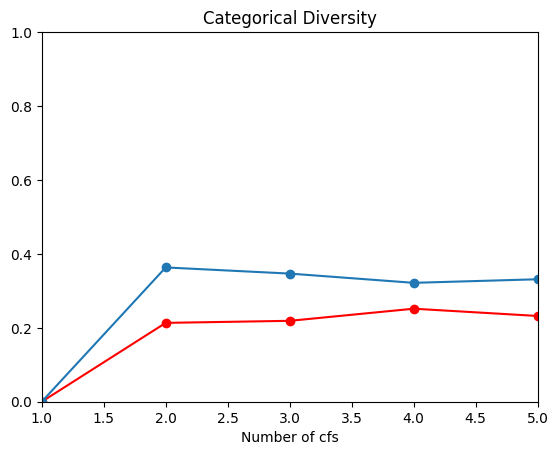

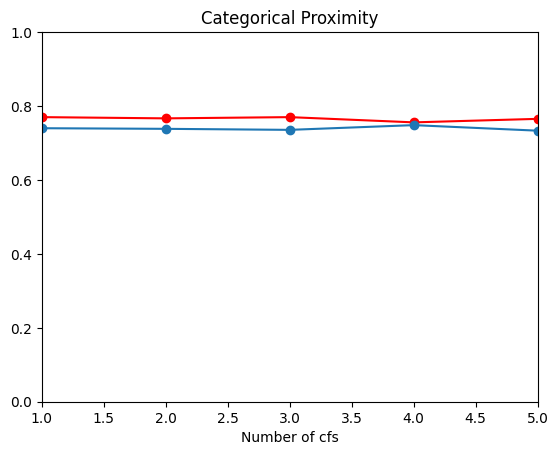

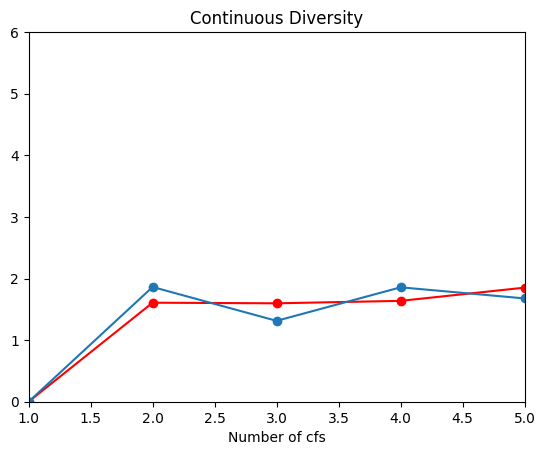

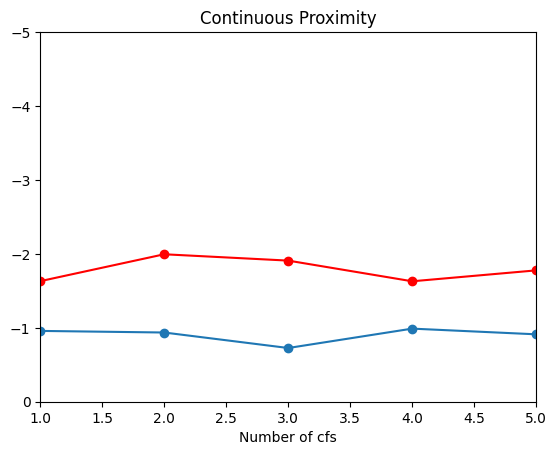

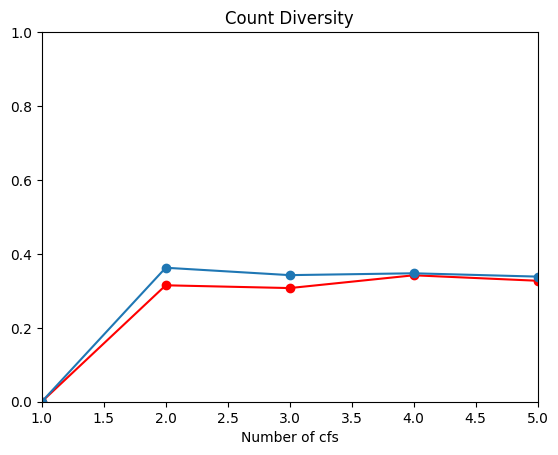

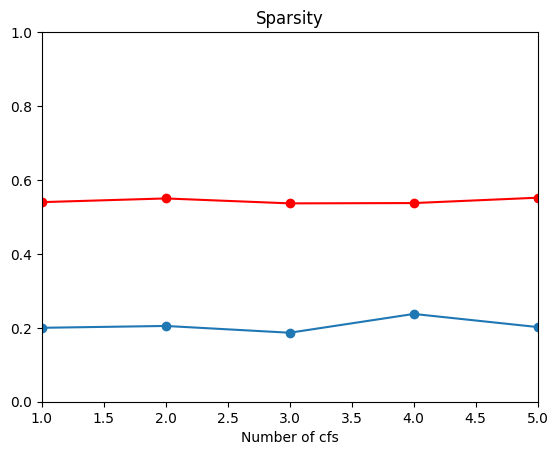

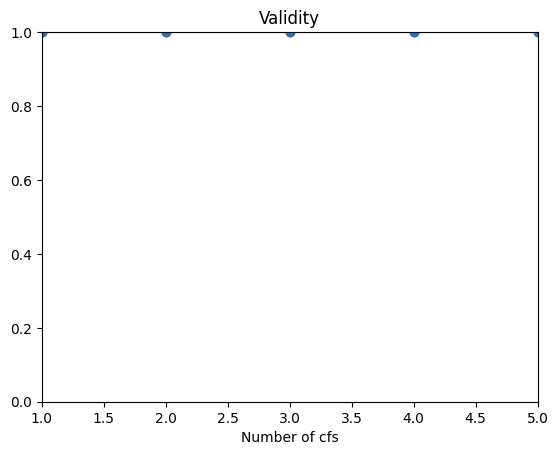

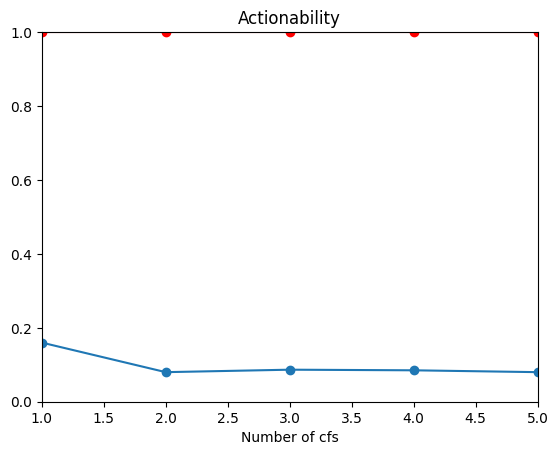

In [ ]:
no_cfs = np.arange(1,6)

compare_values(xcat_div, rcat_div, no_cfs, "Categorical Diversity", ylim=(0,1))
compare_values(xcat_prox, rcat_prox, no_cfs, "Categorical Proximity", ylim=(0,1))
compare_values(xcont_div, rcont_div, no_cfs, "Continuous Diversity", ylim=(0,6))
compare_values(xcont_prox, rcont_prox, no_cfs, "Continuous Proximity", ylim=(0,5))
compare_values(xcount_div, rcount_div, no_cfs, "Count Diversity", ylim=(0,1))
compare_values(xspars, rspars, no_cfs, "Sparsity", ylim=(0,1))
compare_values(xval, rval, no_cfs, "Validity", ylim=(0,1))
compare_values(np.ones(5), ract, no_cfs, "Actionability", ylim=(0,1))

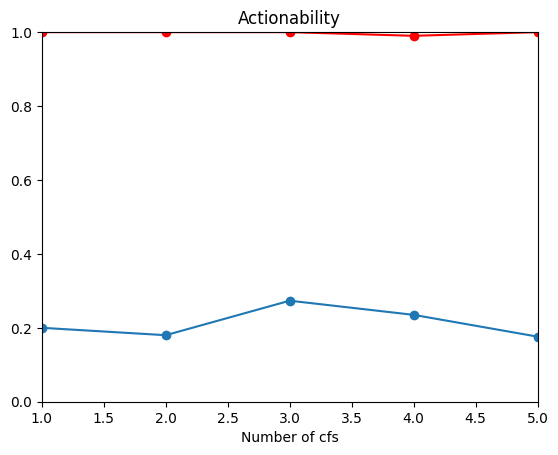

In [159]:
compare_values(xact, ract, no_cfs, "Actionability", ylim=(0,1))